In [5]:
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.visualization import ImageNormalize, LogStretch, SqrtStretch
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from photutils import DAOStarFinder
from astropy.stats import sigma_clipped_stats
from astropy.wcs.utils import proj_plane_pixel_scales
from glob import glob
from stsci.skypac import pamutils
import os
from pprint import pprint as print

plt.style.use("science")
params = {
         'axes.labelsize': 15,
         'axes.titlesize': 25,
         'ytick.labelsize' :12,
         'xtick.labelsize' :12,
         'xtick.major.size': 8,
         'xtick.minor.size': 4,
         'xtick.major.width': 1,
         'xtick.minor.width': 1,
         'ytick.color': "w",
         'xtick.color': "w",
         'axes.labelcolor': "k",
         'ytick.labelcolor' : "k",
         'xtick.labelcolor' : "k",
         }

/tmp/ipykernel_9944/4094683288.py:8: DeprecationWarning: `photutils.DAOStarFinder` is a deprecated alias for `photutils.detection.DAOStarFinder` and will be removed in the future. Instead, please use `from photutils.detection import DAOStarFinder` to silence this warning.
  from photutils import DAOStarFinder


In [27]:
base_path = "/media/alexandre/Seagate/Data/Joseph_targets/"

# Create SkyCoord objects
J030000 = SkyCoord('03h00m00.573s', '+00d48m28.01s', frame='icrs')
J085053 = SkyCoord('08h50m53.125s', '+44d51m22.50s', frame='icrs')
J102036 = SkyCoord('10h20m36.103s', '+60d23m38.96s', frame='icrs')
J105102 = SkyCoord('10h51m02.775s', '+52d50m49.86s', frame='icrs')
J112526 = SkyCoord('11h25m26.126s', '+00d29m01.32s', frame='icrs')

# J030000: PSF dominated, unanalyzable
J030000_drz_path = base_path + 'hst_wfc3_sdssj030000/HST/ICL901010/icl901010_drz.fits'
# J085053: Galaxy found, easiest to analyze.
J085053_drz_path = base_path + 'hst_wfc3_sdssj085053/HST/IB5T05010/ib5t05010_drz.fits'
# J102036: Disturbed galaxy.
J102036_drz_path = base_path + 'hst_wfc3_sdssj102036/HST/ICL903010/icl903010_drz.fits'
# J105102: Galaxy found, easiest to analyze.
J105102_drz_path = base_path + 'hst_wfc3_sdssj105102/HST/IB5T10010/ib5t10010_drz.fits'
# J112526: PSF dominated, unanalyzable.
J112526_drz_path = base_path + 'hst_wfc3_sdssj112526/HST/ICL904010/icl904010_drz.fits'

# Define the paths
base_paths = [base_path + 'hst_wfc3_sdssj030000/HST/ICL901010/',
              base_path + 'hst_wfc3_sdssj085053/HST/IB5T05010/',
              base_path + 'hst_wfc3_sdssj102036/HST/ICL903010/',
              base_path + 'hst_wfc3_sdssj105102/HST/IB5T10010/',
              base_path + 'hst_wfc3_sdssj112526/HST/ICL904010/']

# Create lists of 'flt' fits files
flt_paths = [glob(p + '*_flt.fits') for p in base_paths]

# The 'flt_paths' variable now contains five lists, one for each base path,
# with the paths to the 'flt' fits files. You can access them like this:
J030000_flt_paths, J085053_flt_paths, J102036_flt_paths, J105102_flt_paths, J112526_flt_paths = flt_paths

# Perusing DRZ files

## First, explore one of the targets

In [28]:
data = fits.open(J085053_drz_path)
wcs = WCS(data["SCI"].header)
coord = J085053
# data["SCI"].header

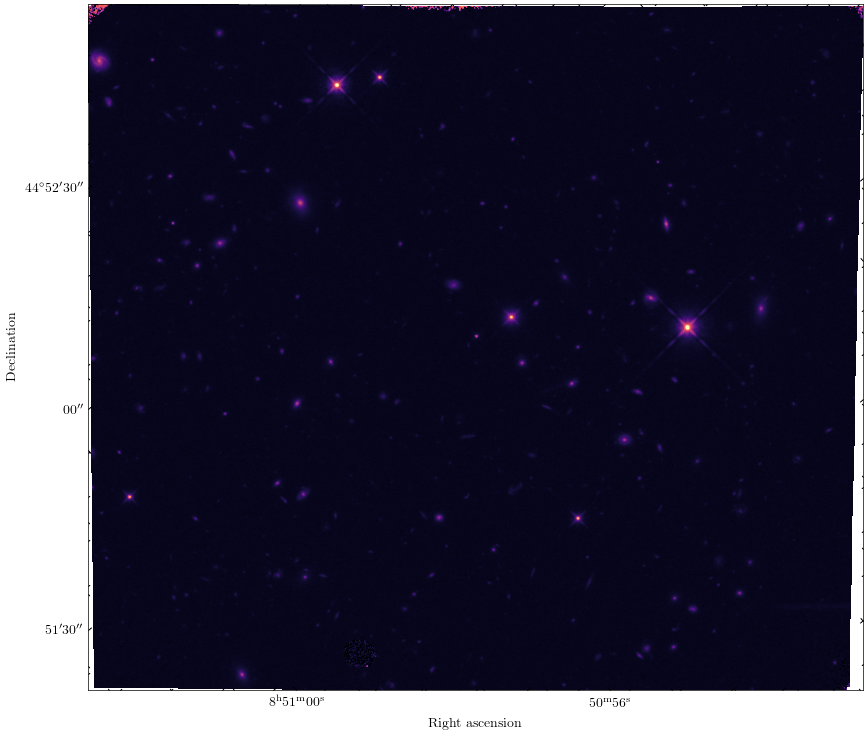

In [29]:
fig = plt.figure(figsize=(10, 10))
fig.add_subplot(projection=wcs)
plt.imshow(data["SCI"].data, cmap="magma", norm=ImageNormalize(vmax=500, vmin=0.5, stretch=LogStretch()))
plt.xlabel("Right ascension")
plt.ylabel("Declination")

In [30]:
size = 64 * u.pixel
cutout = Cutout2D(data["SCI"].data, coord, size, wcs=wcs)

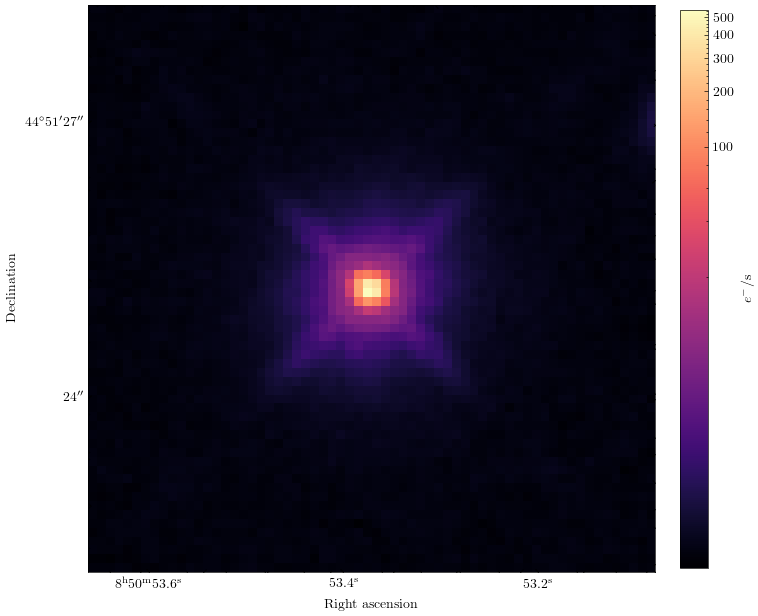

In [31]:
# wcs = WCS(data["SCI"].header)
fig = plt.figure(figsize=(8, 8))
fig.add_subplot(projection=cutout.wcs)
plt.imshow(cutout.data, cmap="magma", norm=ImageNormalize(stretch=LogStretch()))
plt.colorbar(label=r"$e^{-}$/s", fraction=0.045, pad=0.04)
plt.ylabel("Declination")
plt.xlabel("Right ascension")

## Collect all cutouts in a more systematic way

In [32]:
# Do this for every target and plot their flts

# Dictionary of SkyCoord objects
coords = {
    "J030000": J030000,
    "J085053": J085053,
    "J102036": J102036,
    "J105102": J105102,
    "J112526": J112526
}
# Dictionary of drz file paths
drz_paths = {
    "J030000": J030000_drz_path,
    "J085053": J085053_drz_path,
    "J102036": J102036_drz_path,
    "J105102": J105102_drz_path,
    "J112526": J112526_drz_path
}
# Define the size of the cutout
size = 64 * u.pixel
# Create a dictionary to hold the cutouts
drz_cutouts = {}
# Loop over the coords and paths
for key in coords.keys():
    # Load the data
    data = fits.open(drz_paths[key])
    # Extract the WCS
    wcs = WCS(data["SCI"].header)
    # Perform the cutout
    cutout = Cutout2D(data["SCI"].data, coords[key], size, wcs=wcs)
    # Store the cutout in the dictionary
    drz_cutouts[key] = cutout

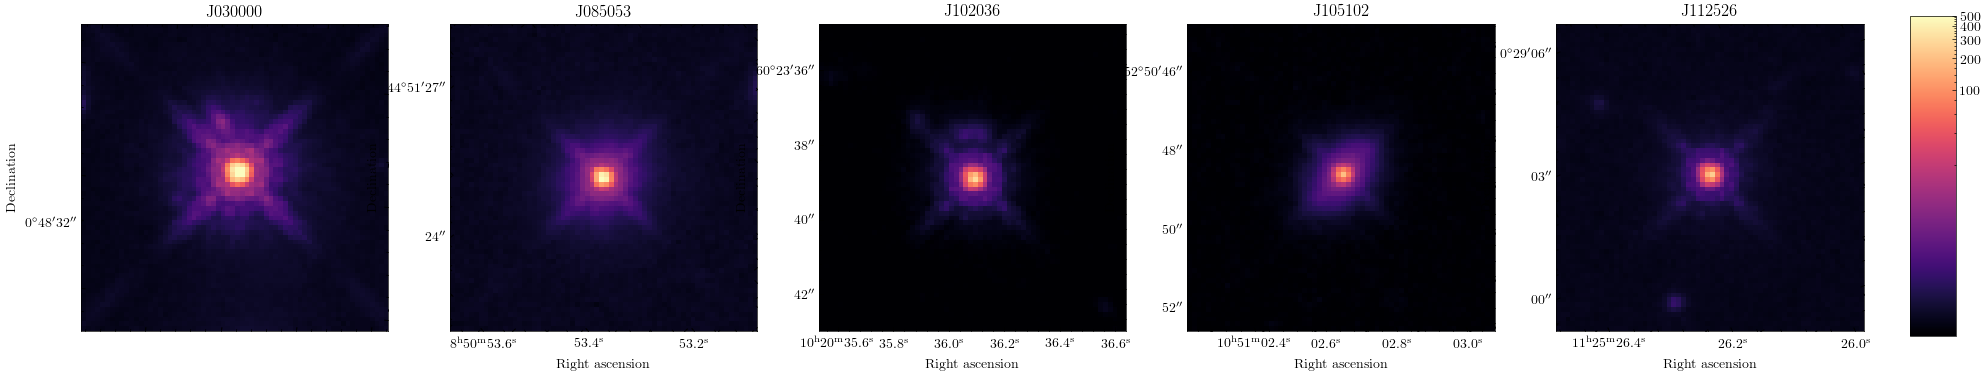

In [33]:
# Create a figure
fig = plt.figure(figsize=(23, 4))
# Number of subplots
n = len(drz_cutouts)
# Loop over the cutouts and create a subplot for each
for i, (key, cutout) in enumerate(drz_cutouts.items()):
    ax = fig.add_subplot(1, n, i+1, projection=cutout.wcs)
    ax.set_ylabel("Declination")
    ax.set_xlabel("Right ascension")
    im = ax.imshow(cutout.data, cmap="magma", norm=ImageNormalize(stretch=LogStretch(), vmax=500, vmin=0.5))
    ax.set_title(key)
ax2 = fig.add_axes([0.92, 0.1, 0.02, 0.8])
fig.colorbar(im, cax=ax2)

# Collating FLT files for analysis 

In [34]:
# Dictionary of lists of flt file paths
flt_paths = {
    "J030000": J030000_flt_paths,
    "J085053": J085053_flt_paths,
    "J102036": J102036_flt_paths,
    "J105102": J105102_flt_paths,
    "J112526": J112526_flt_paths
}

# Create a dictionary to hold the cutouts
flt_cutouts = {}
# Define the size of the cutout
size = 64 * u.pixel
# Loop over the coords and paths
for key in coords.keys():
    flt_cutouts[key] = []  # Initialize the list of cutouts for this key
    for path in flt_paths[key]:
        # Load the data
        data = fits.open(path)
        # Extract the WCS
        wcs = WCS(data["SCI"].header)
        # Perform the cutout
        cutout = Cutout2D(data["SCI"].data, coords[key], size, wcs=wcs)
        # Add the cutout to the list
        flt_cutouts[key].append(cutout)

In [35]:
for key in flt_paths.keys():
    print(key)
    for i in range(len(flt_paths[key])):
        data = fits.open(flt_paths[key][i])
        date = data[0].header["DATE-OBS"]
        time = data[0].header["TIME-OBS"]
        unit = data["SCI"].header["BUNIT"]
        print(f"Date {date} | Time {time} | Units {unit}")

'J030000'
'Date 2014-12-08 | Time 14:56:51 | Units ELECTRONS/S'
'Date 2014-12-08 | Time 15:02:14 | Units ELECTRONS/S'
'Date 2014-12-08 | Time 15:07:37 | Units ELECTRONS/S'
'Date 2014-12-08 | Time 15:13:08 | Units ELECTRONS/S'
'Date 2014-12-08 | Time 15:18:31 | Units ELECTRONS/S'
'Date 2014-12-08 | Time 15:23:54 | Units ELECTRONS/S'
'Date 2014-12-08 | Time 15:29:25 | Units ELECTRONS/S'
'Date 2014-12-08 | Time 15:34:48 | Units ELECTRONS/S'
'Date 2014-12-08 | Time 15:40:11 | Units ELECTRONS/S'
'J085053'
'Date 2010-04-09 | Time 07:20:28 | Units ELECTRONS/S'
'Date 2010-04-09 | Time 07:29:03 | Units ELECTRONS/S'
'J102036'
'Date 2014-10-15 | Time 19:49:51 | Units ELECTRONS/S'
'Date 2014-10-15 | Time 19:55:14 | Units ELECTRONS/S'
'Date 2014-10-15 | Time 20:00:37 | Units ELECTRONS/S'
'Date 2014-10-15 | Time 20:06:08 | Units ELECTRONS/S'
'Date 2014-10-15 | Time 20:11:31 | Units ELECTRONS/S'
'Date 2014-10-15 | Time 20:16:54 | Units ELECTRONS/S'
'Date 2014-10-15 | Time 20:22:25 | Units ELECTRONS/S

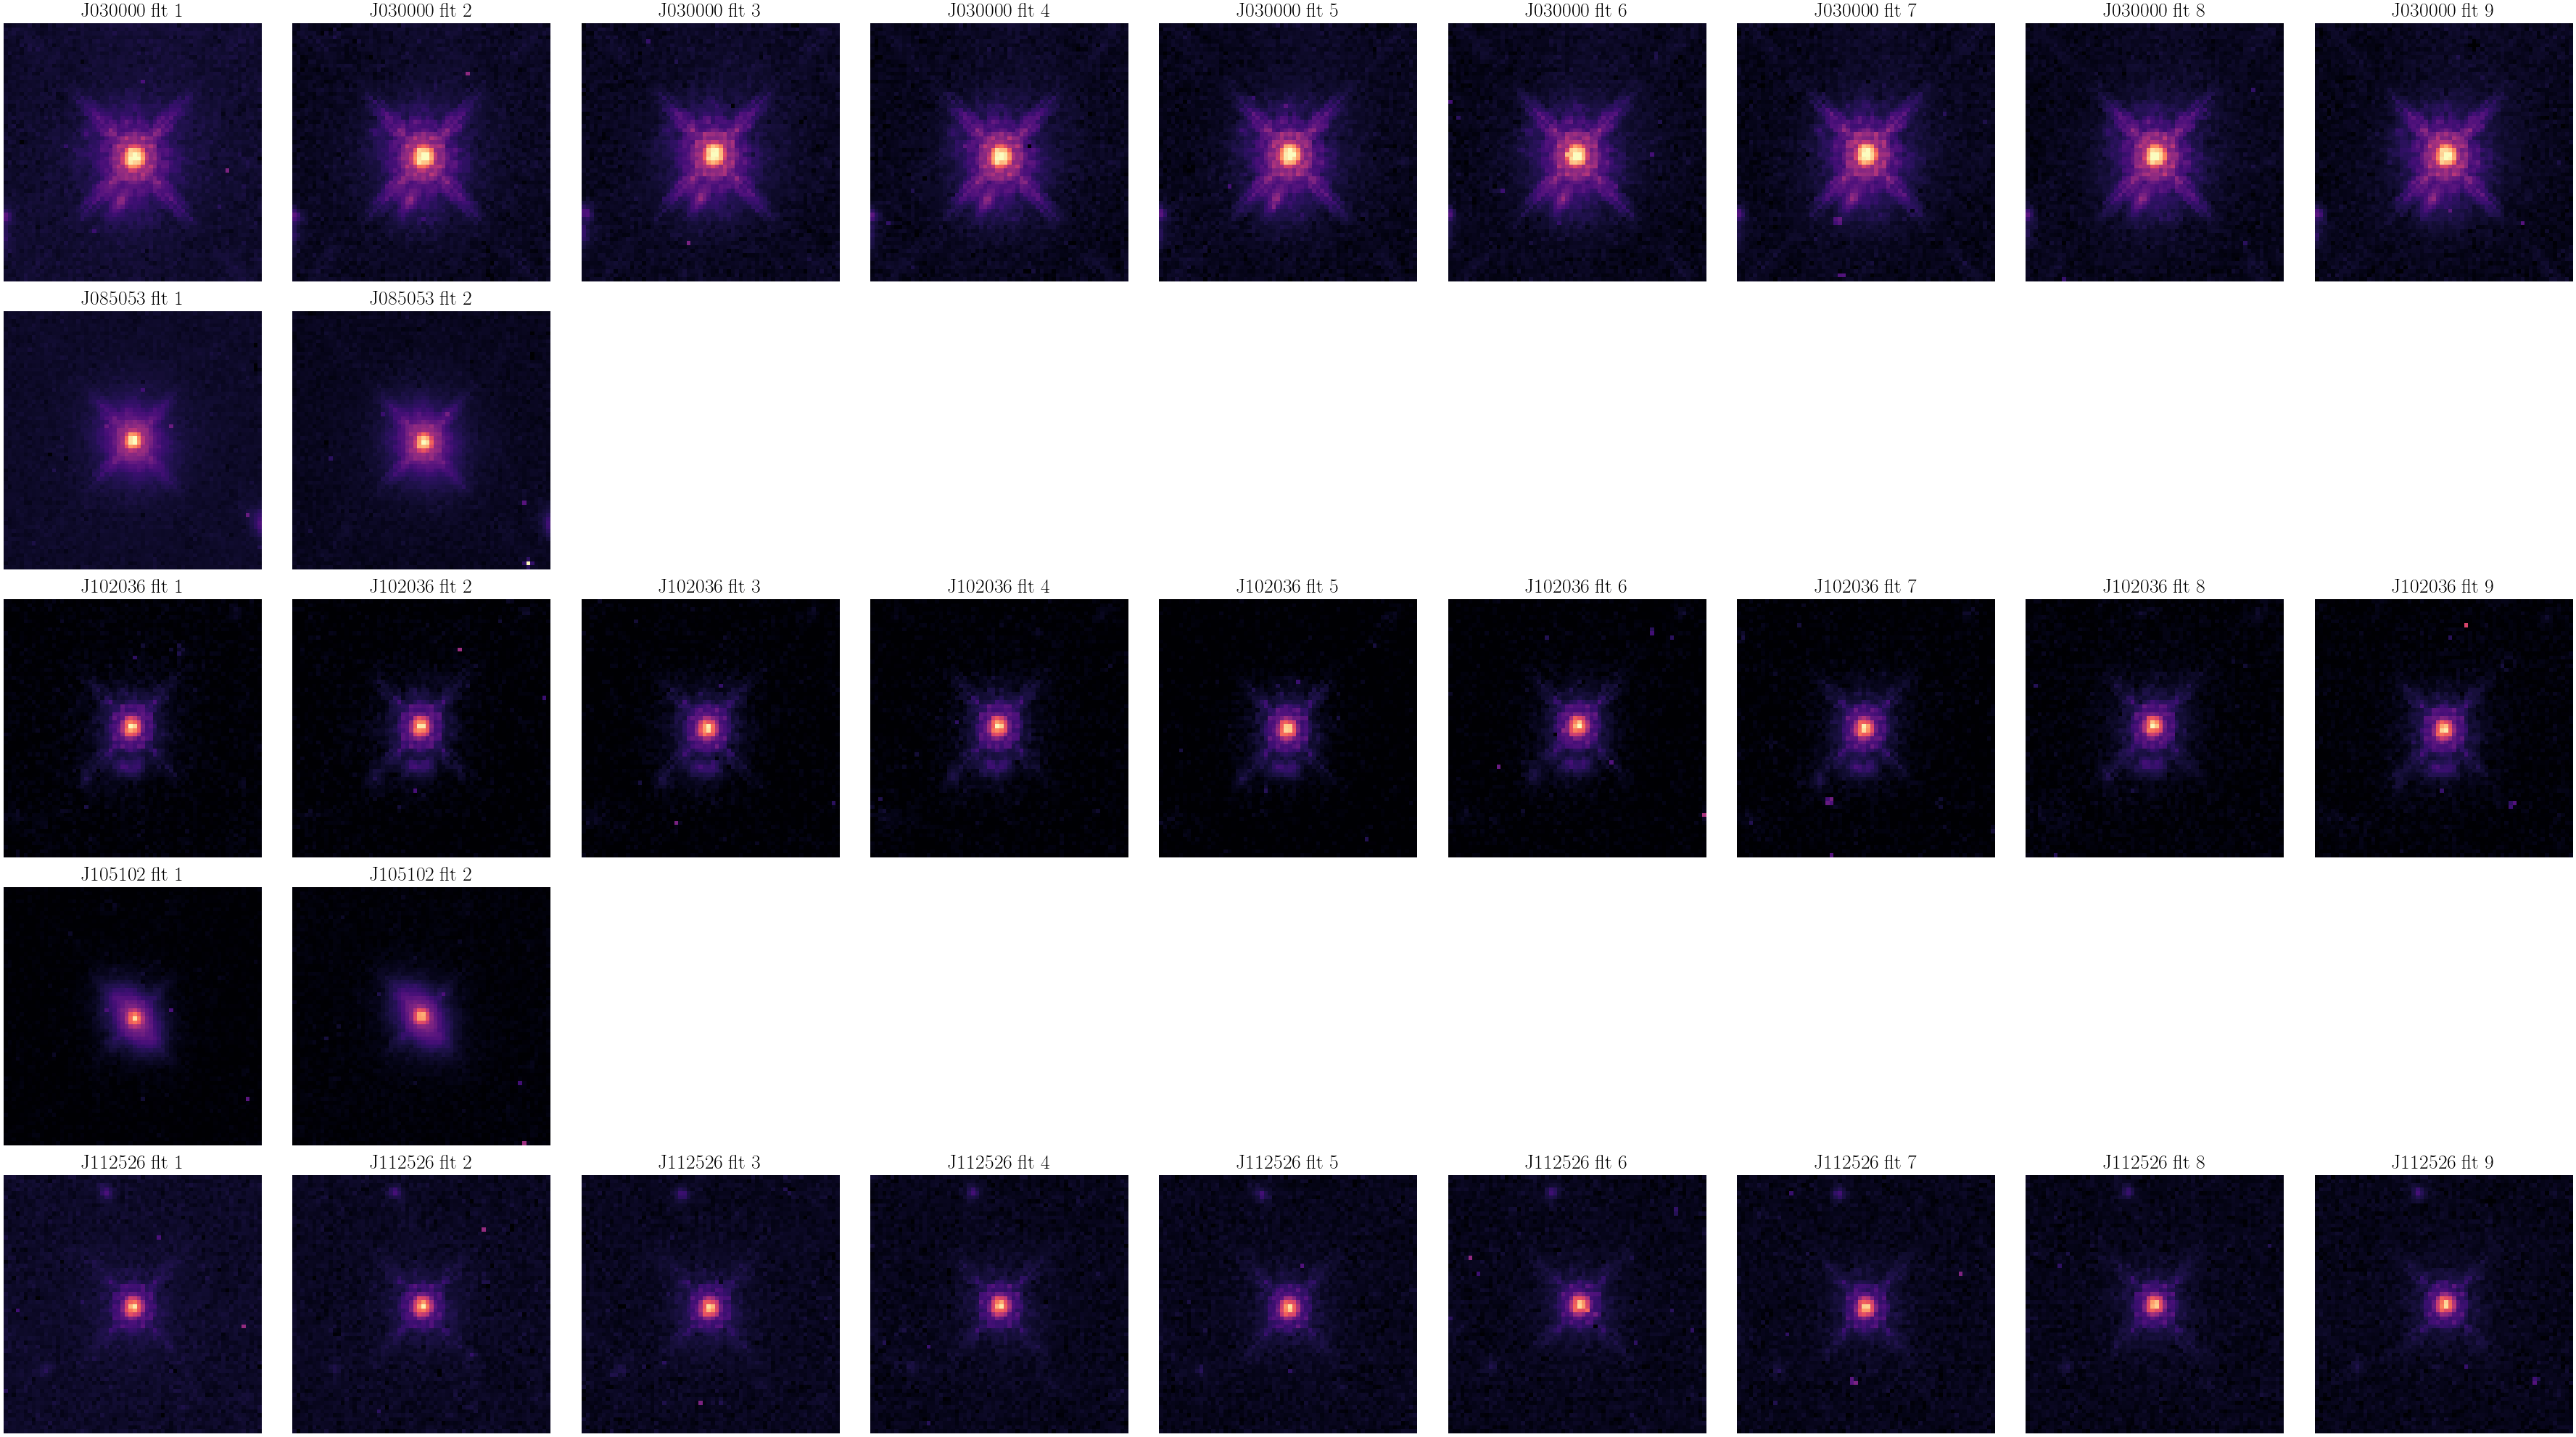

In [39]:
# Get the maximum number of flt files for any target
max_flt_files = max(len(flt_cutouts[key]) for key in flt_cutouts)

# Create a figure
fig, axs = plt.subplots(len(flt_cutouts), max_flt_files, figsize=(max_flt_files*4, 20), squeeze=False)

# Loop over the targets
for i, (key, cutouts) in enumerate(flt_cutouts.items()):
    # Loop over the cutouts for this target
    for j, cutout in enumerate(cutouts):
        # Create a subplot for this cutout
        ax = axs[i, j]
        im = ax.imshow(cutout.data, cmap="magma", norm=ImageNormalize(stretch=LogStretch(), vmax=500, vmin=0.5))
        ax.set_title(f"{key} flt {j+1}", fontsize=20)
        ax.axis("off")

# Remove empty subplots
for ax in axs.flatten():
    if not len(ax.images):
        fig.delaxes(ax)

plt.tight_layout()

# Compute noise statistics from dark sky

In [41]:
three_sigmas = {key: [] for key in flt_paths.keys()}
dark_sky_modes = {key: [] for key in flt_paths.keys()}
for key in flt_paths.keys():
    print(key)
    for i in range(len(flt_paths[key])):
        data = fits.open(flt_paths[key][i])
        exptime = data[0].header["EXPTIME"]
        # Don't renormalize since units are already e/s
        temp = data["SCI"].data.ravel() #/ exptime
        dark_sky = temp[(temp > 0.4) & (temp < 3)] 
        dark_sky_modes[key].append(np.quantile(dark_sky, 0.5))
    #     break
    # break

'J030000'
'J085053'
'J102036'
'J105102'
'J112526'


In [42]:
# plt.hist(dark_sky.ravel()[dark_sky.ravel() < 1.5], bins=100);

In [43]:
dark_sky_modes

{'J030000': [0.8312390744686127,
  0.7037607431411743,
  0.6942991018295288,
  0.661860853433609,
  0.6538979113101959,
  0.6485221982002258,
  0.6503334045410156,
  0.6447938978672028,
  0.6375328898429871],
 'J085053': [0.8271902799606323, 0.7258675694465637],
 'J102036': [0.5295318365097046,
  0.5109422206878662,
  0.5098633766174316,
  0.5135297179222107,
  0.48723144829273224,
  0.5047268271446228,
  0.5144611597061157,
  0.545019805431366,
  0.5395073890686035],
 'J105102': [0.5140255093574524, 0.5455256104469299],
 'J112526': [0.8300772309303284,
  0.7568417191505432,
  0.7320636808872223,
  0.7021748423576355,
  0.7044586539268494,
  0.6896528005599976,
  0.6863939762115479,
  0.6848449110984802,
  0.6804095506668091]}

# Save the data

In [47]:
for i, (key, cutouts) in enumerate(flt_cutouts.items()):
    print(key)
    drz_data = fits.open(drz_paths[key])
    hdu_p = fits.PrimaryHDU(header=drz_data[0].header)
    drz = fits.ImageHDU(drz_cutouts[key].data, name="drz", header=drz_cutouts[key].wcs.to_header())
    flcs = []
    for j, cutout in enumerate(cutouts):
        original_flts = fits.open(flt_paths

        dark_sky = dark_sky_modes[key][j] # use the measured (detector specific) dark sky flux measurement 
        # print(dark_sky)
        pam = pamutils.pam_from_wcs(cutout.wcs) # pixel area map read from distortion table coefficients in fits file
        # exptime = fits.open(flc_paths[key][i])[0].header["EXPTIME"]
        flcs.append(fits.ImageHDU(cutout.data * pam - dark_sky, name="flc", ver=j+1, header=cutout.wcs.to_header()))
    
    hdul = fits.HDUList([hdu_p, drz] + flcs)
    hdul.writeto(f"../data/joseph_target_{key}.fits", overwrite=True)

'J030000'
'J085053'
'J102036'
'J105102'
'J112526'


WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP'  'DEC--TAN-SIP'  
CRVAL : 45.001789610831  0.80721417169322  
CRPIX : 49.0  49.0  
CD1_1 CD1_2  : -3.765325478164e-06  -3.34412545536e-05  
CD2_1 CD2_2  : -3.7428143357997e-05  3.2526935551867e-06  
NAXIS : 64  64

In [65]:
fits.open("../data/joseph_target_J030000.fits").info()

Filename: ../data/joseph_target_J030000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     909   ()      
  1  DRZ           1 ImageHDU        30   (64, 64)   float32   
  2  FLC           1 ImageHDU        31   (64, 64)   float64   
  3  FLC           2 ImageHDU        31   (64, 64)   float64   
  4  FLC           3 ImageHDU        31   (64, 64)   float64   
  5  FLC           4 ImageHDU        31   (64, 64)   float64   
  6  FLC           5 ImageHDU        31   (64, 64)   float64   
  7  FLC           6 ImageHDU        31   (64, 64)   float64   
  8  FLC           7 ImageHDU        31   (64, 64)   float64   
  9  FLC           8 ImageHDU        31   (64, 64)   float64   
 10  FLC           9 ImageHDU        31   (64, 64)   float64   


In [72]:
my_wcs = WCS(fits.open("../data/joseph_target_J030000.fits")[3].header)
original_wcs = flt_cutouts["J030000"][1].wcs

In [73]:
my_wcs.world_to_pixel(J030000)

(array(31.53428758), array(31.84348307))

In [74]:
original_wcs.world_to_pixel(J030000)

(array(31.65340513), array(31.68631432))

In [82]:
flt_paths["J030000"]

['/media/alexandre/Seagate/Data/Joseph_targets/hst_wfc3_sdssj030000/HST/ICL901010/icl901ezq_flt.fits',
 '/media/alexandre/Seagate/Data/Joseph_targets/hst_wfc3_sdssj030000/HST/ICL901010/icl901f0q_flt.fits',
 '/media/alexandre/Seagate/Data/Joseph_targets/hst_wfc3_sdssj030000/HST/ICL901010/icl901f2q_flt.fits',
 '/media/alexandre/Seagate/Data/Joseph_targets/hst_wfc3_sdssj030000/HST/ICL901010/icl901f4q_flt.fits',
 '/media/alexandre/Seagate/Data/Joseph_targets/hst_wfc3_sdssj030000/HST/ICL901010/icl901f6q_flt.fits',
 '/media/alexandre/Seagate/Data/Joseph_targets/hst_wfc3_sdssj030000/HST/ICL901010/icl901f8q_flt.fits',
 '/media/alexandre/Seagate/Data/Joseph_targets/hst_wfc3_sdssj030000/HST/ICL901010/icl901faq_flt.fits',
 '/media/alexandre/Seagate/Data/Joseph_targets/hst_wfc3_sdssj030000/HST/ICL901010/icl901fcq_flt.fits',
 '/media/alexandre/Seagate/Data/Joseph_targets/hst_wfc3_sdssj030000/HST/ICL901010/icl901fdq_flt.fits']

In [ ]:
data_wcs

Filename: /media/alexandre/Seagate/Data/Joseph_targets/hst_wfc3_sdssj030000/HST/ICL901010/icl901ezq_flt.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     278   ()      
  1  SCI           1 ImageHDU       185   (1014, 1014)   float32   
  2  ERR           1 ImageHDU        48   (1014, 1014)   float32   
  3  DQ            1 ImageHDU        40   (1014, 1014)   int16   
  4  SAMP          1 ImageHDU        34   (1014, 1014)   int16   
  5  TIME          1 ImageHDU        34   (1014, 1014)   float32   
  6  HDRLET        1 HeaderletHDU     17   ()      
  7  HDRLET        2 HeaderletHDU     17   ()      
  8  HDRLET        3 HeaderletHDU     17   ()      
  9  HDRLET        4 HeaderletHDU     17   ()      
 10  HDRLET        5 HeaderletHDU     17   ()      
 11  HDRLET        6 HeaderletHDU     17   ()      
 12  HDRLET        7 HeaderletHDU     17   ()      
 13  WCSCORR       1 BinTableHDU     59   7R x 24C   [40A, I, A, 24A, 24A, 24A

In [86]:
data_wcs = WCS(fits.open(flt_paths["J030000"][0])["SCI"])
wcs1 = flt_cutouts["J030000"][0].wcs

In [89]:
wcs1.world_to_pixel(J030000)

(array(31.4691094), array(31.97402057))

In [91]:
dir(wcs1)

['__abstractmethods__',
 '__class__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_all_pix2world',
 '_all_world2pix',
 '_array_converter',
 '_as_mpl_axes',
 '_components_and_classes_cache',
 '_denormalize_sky',
 '_det2im',
 '_fix_ctype',
 '_fix_pre2012_scamp_tpv',
 '_fix_scamp',
 '_get_components_and_classes',
 '_get_naxis',
 '_init_kwargs',
 '_naxis',
 '_normalize_sky',
 '_p4_pix2foc',
 '_pix2foc',
 '_pixel_bounds',
 '_read_d2im_old_format',
 '_read_det2im_kw',
 '_read_distortion_kw',
 '_read_sip_kw',
 '_remove_sip_kw',
 '_write_det2im',
 '_write_distortion_kw',
 '_write_sip_kw',
 'all_pix2world',
 'all_w